In [1]:
import numpy as np
from jetgp.full_degp.degp import degp
import matplotlib.pyplot as plt

print("Modules imported successfully.")

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


Modules imported successfully.


In [2]:
X_train = np.array([[0.0], [0.5], [1.0]])
y_func = np.sin(X_train)
y_deriv1 = np.cos(X_train)
y_train = [y_func, y_deriv1]

print("X_train:", X_train)
print("y_train:", y_train)

X_train: [[0. ]
 [0.5]
 [1. ]]
y_train: [array([[0.        ],
       [0.47942554],
       [0.84147098]]), array([[1.        ],
       [0.87758256],
       [0.54030231]])]


In [3]:
der_indices = [[[[1, 1]]]]

# derivative_locations must be provided - one entry per derivative
derivative_locations = []
for i in range(len(der_indices)):
   for j in range(len(der_indices[i])):
         derivative_locations.append([k for k in range(len(X_train))])

print("der_indices:", der_indices)
print("derivative_locations:", derivative_locations)

der_indices: [[[[1, 1]]]]
derivative_locations: [[0, 1, 2]]


In [4]:
model = degp(X_train, y_train, n_order=1, n_bases=1,
             der_indices=der_indices,
             derivative_locations=derivative_locations,
             normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("DEGP model initialized.")

DEGP model initialized.


In [5]:
params =  model.optimize_hyperparameters(
     optimizer='pso',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = 15,
     debug = False
     )
print("Optimized hyperparameters:", params)

Stopping: maximum iterations reached --> 15
Optimized hyperparameters: [-0.79461808  0.74787037 -6.90795194]


In [6]:
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)

# Output shape is [n_derivatives + 1, n_points]
# Row 0: function values, Row 1: first derivative
y_func_pred = y_train_pred[0, :]
y_deriv_pred = y_train_pred[1, :]

abs_error_func = np.abs(y_func_pred.flatten() - y_func.flatten())
abs_error_deriv = np.abs(y_deriv_pred.flatten() - y_deriv1.flatten())

print("Absolute error (function) at training points:", abs_error_func)
print("Absolute error (derivative) at training points:", abs_error_deriv)

Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]]]
Absolute error (function) at training points: [2.08221773e-11 1.36352041e-12 1.31896716e-11]
Absolute error (derivative) at training points: [2.15107931e-11 8.35553848e-11 2.20210516e-11]


Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]]]


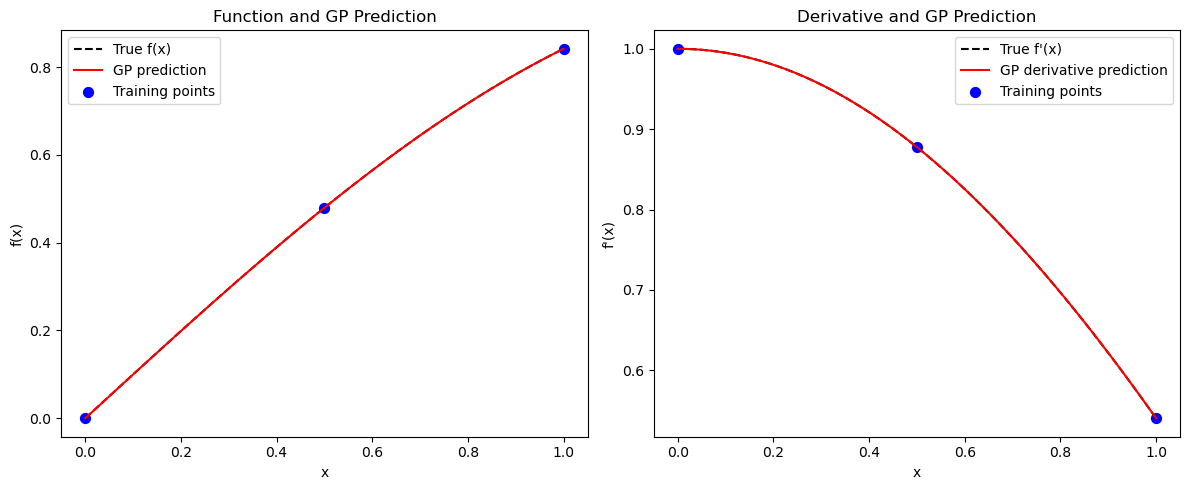

In [7]:
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)

# Row 0: function, Row 1: first derivative
y_func_test = y_test_pred[0, :]
y_deriv_test = y_test_pred[1, :]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(X_test, np.sin(X_test), 'k--', label='True f(x)')
plt.plot(X_test, y_func_test, 'r-', label='GP prediction')
plt.scatter(X_train, y_func, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function and GP Prediction')
plt.legend()

plt.subplot(1,2,2)
plt.plot(X_test, np.cos(X_test), 'k--', label="True f'(x)")
plt.plot(X_test, y_deriv_test, 'r-', label='GP derivative prediction')
plt.scatter(X_train, y_deriv1, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('Derivative and GP Prediction')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
X_train = np.array([[0.0], [0.5], [1.0]])
y_func = np.sin(X_train)
y_deriv1 = np.cos(X_train)
y_deriv2 = -np.sin(X_train)
y_train = [y_func, y_deriv1, y_deriv2]

print("X_train:", X_train)
print("y_train:", y_train)

X_train: [[0. ]
 [0.5]
 [1. ]]
y_train: [array([[0.        ],
       [0.47942554],
       [0.84147098]]), array([[1.        ],
       [0.87758256],
       [0.54030231]]), array([[-0.        ],
       [-0.47942554],
       [-0.84147098]])]


In [9]:
der_indices = [[[[1, 1]], [[1, 2]]]]

# All derivatives at all training points
derivative_locations = []
for i in range(len(der_indices)):
   for j in range(len(der_indices[i])):
         derivative_locations.append([k for k in range(len(X_train))])

print("der_indices:", der_indices)
print("derivative_locations:", derivative_locations)

der_indices: [[[[1, 1]], [[1, 2]]]]
derivative_locations: [[0, 1, 2], [0, 1, 2]]


In [10]:
model = degp(X_train, y_train, n_order=2, n_bases=1,
             der_indices=der_indices,
             derivative_locations=derivative_locations,
             normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("DEGP model (2nd order) initialized.")

DEGP model (2nd order) initialized.


In [11]:
params = model.optimize_hyperparameters(
     optimizer='pso',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = 15,
     debug = True
     )
print("Optimized hyperparameters:", params)

Best after iteration 1: [-0.49809153  0.1613333  -7.35810342] -27.905543664190425
Best after iteration 2: [-0.49809153  0.1613333  -7.35810342] -27.905543664190425
New best for swarm at iteration 3: [-0.71139928  1.11402466 -9.13271326] -31.743271693104
Best after iteration 3: [-0.71139928  1.11402466 -9.13271326] -31.743271693104
New best for swarm at iteration 4: [-0.6333303   0.44284355 -7.11229653] -36.01459344964242
New best for swarm at iteration 4: [-0.80947773  0.96698157 -6.3313405 ] -38.28070417133697
Best after iteration 4: [-0.80947773  0.96698157 -6.3313405 ] -38.28070417133697
New best for swarm at iteration 5: [-0.68856077  0.60248248 -9.43878771] -38.46012121476042
New best for swarm at iteration 5: [-0.89899728  0.96066334 -7.98666417] -38.652392806454294
New best for swarm at iteration 5: [-0.73627163  0.61901839 -7.96359276] -41.104583066563926
Best after iteration 5: [-0.73627163  0.61901839 -7.96359276] -41.104583066563926
Best after iteration 6: [-0.73627163  0.61

Best after iteration 14: [-0.80631196  0.70901394 -7.96901253] -43.639244938234064


Local optimization did not improve:
Best after iteration 15: [-0.80631196  0.70901394 -7.96901253] -43.639244938234064
Stopping: maximum iterations reached --> 15
Optimized hyperparameters: [-0.80631196  0.70901394 -7.96901253]


In [12]:
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)

# Output shape is [n_derivatives + 1, n_points]
# Row 0: function, Row 1: 1st derivative, Row 2: 2nd derivative
y_func_pred = y_train_pred[0, :]
y_deriv1_pred = y_train_pred[1, :]
y_deriv2_pred = y_train_pred[2, :]

abs_error_func = np.abs(y_func_pred.flatten() - y_func.flatten())
abs_error_deriv1 = np.abs(y_deriv1_pred.flatten() - y_deriv1.flatten())
abs_error_deriv2 = np.abs(y_deriv2_pred.flatten() - y_deriv2.flatten())

print("Absolute error (function) at training points:", abs_error_func)
print("Absolute error (1st derivative) at training points:", abs_error_deriv1)
print("Absolute error (2nd derivative) at training points:", abs_error_deriv2)

Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[1, 2]]]
Absolute error (function) at training points: [2.01498801e-09 1.88591603e-09 2.18252416e-09]
Absolute error (1st derivative) at training points: [2.61829447e-10 4.83574625e-10 1.36038070e-10]
Absolute error (2nd derivative) at training points: [6.58243982e-11 1.29837363e-10 5.41167999e-10]


Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[1, 2]]]


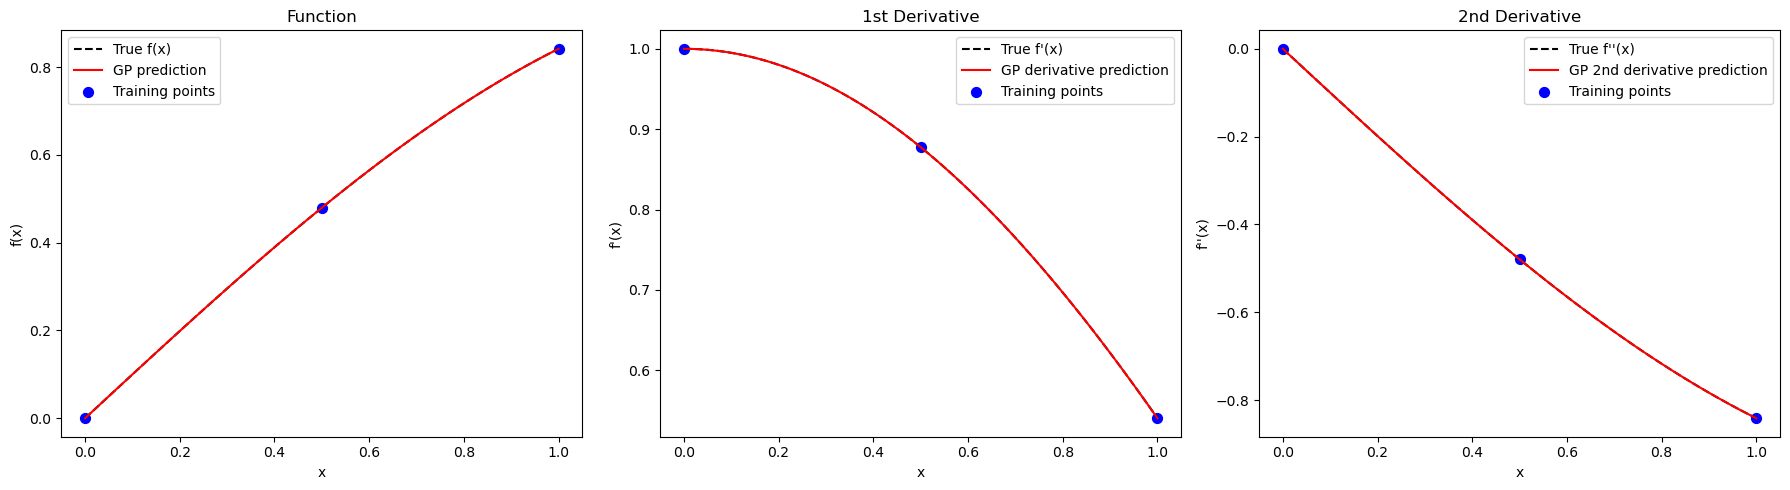

In [13]:
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)

# Row 0: function, Row 1: 1st derivative, Row 2: 2nd derivative
y_func_test = y_test_pred[0, :]
y_deriv1_test = y_test_pred[1, :]
y_deriv2_test = y_test_pred[2, :]

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(X_test, np.sin(X_test), 'k--', label='True f(x)')
plt.plot(X_test, y_func_test, 'r-', label='GP prediction')
plt.scatter(X_train, y_func, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function')
plt.legend()

plt.subplot(1,3,2)
plt.plot(X_test, np.cos(X_test), 'k--', label="True f'(x)")
plt.plot(X_test, y_deriv1_test, 'r-', label='GP derivative prediction')
plt.scatter(X_train, y_deriv1, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('1st Derivative')
plt.legend()

plt.subplot(1,3,3)
plt.plot(X_test, -np.sin(X_test), 'k--', label="True f''(x)")
plt.plot(X_test, y_deriv2_test, 'r-', label='GP 2nd derivative prediction')
plt.scatter(X_train, y_deriv2, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel("f''(x)")
plt.title('2nd Derivative')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
from jetgp.full_degp.degp import degp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Modules imported successfully for 2D example.")

Modules imported successfully for 2D example.


In [15]:
X1 = np.array([0.0, 0.5, 1.0])
X2 = np.array([0.0, 0.5, 1.0])
X1_grid, X2_grid = np.meshgrid(X1, X2)
X_train = np.column_stack([X1_grid.flatten(), X2_grid.flatten()])

y_func = np.sin(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_x = np.cos(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_y = -np.sin(X_train[:,0]) * np.sin(X_train[:,1])
y_train = [y_func.reshape(-1,1), y_deriv_x.reshape(-1,1), y_deriv_y.reshape(-1,1)]

print("X_train shape:", X_train.shape)
print("y_train shapes:", [v.shape for v in y_train])

X_train shape: (9, 2)
y_train shapes: [(9, 1), (9, 1), (9, 1)]


In [16]:
der_indices = [[[[1, 1]], [[2, 1]]]]

# All derivatives at all training points
derivative_locations = []
for i in range(len(der_indices)):
   for j in range(len(der_indices[i])):
         derivative_locations.append([k for k in range(len(X_train))])

print("der_indices:", der_indices)
print("derivative_locations:", derivative_locations)

der_indices: [[[[1, 1]], [[2, 1]]]]
derivative_locations: [[0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8]]


In [17]:
model = degp(X_train, y_train, n_order=1, n_bases=2,
             der_indices=der_indices,
             derivative_locations=derivative_locations,
             normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("2D DEGP model initialized.")

2D DEGP model initialized.


In [18]:
params = model.optimize_hyperparameters(
     optimizer='pso',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = 15,
     debug = False
     )
print("Optimized hyperparameters:", params)

Stopping: maximum iterations reached --> 15
Optimized hyperparameters: [ -0.66747025  -0.73723361   0.67303613 -12.06121052]


In [19]:
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)

# Output shape is [n_derivatives + 1, n_points]
# Row 0: function, Row 1: df/dx, Row 2: df/dy
y_func_pred = y_train_pred[0, :]
y_deriv_x_pred = y_train_pred[1, :]
y_deriv_y_pred = y_train_pred[2, :]

print("Predictions at training points (function):", y_func_pred)
print("Predictions at training points (deriv x):", y_deriv_x_pred)
print("Predictions at training points (deriv y):", y_deriv_y_pred)

Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[2, 1]]]
Predictions at training points (function): [-7.61202767e-11  4.79425538e-01  8.41470985e-01 -5.55030466e-11
  4.20735492e-01  7.38460263e-01 -3.67847419e-11  2.59034724e-01
  4.54648713e-01]
Predictions at training points (deriv x): [1.         0.87758256 0.54030231 0.87758256 0.77015115 0.47415988
 0.54030231 0.47415988 0.29192658]
Predictions at training points (deriv y): [-3.15635985e-11  6.97721652e-12 -1.99349043e-11 -1.09641974e-11
 -2.29848847e-01 -4.03422680e-01 -4.65147768e-12 -4.03422680e-01
 -7.08073418e-01]


In [20]:
abs_error_func = np.abs(y_func_pred.flatten() - y_func)
abs_error_dx = np.abs(y_deriv_x_pred.flatten() - y_deriv_x)
abs_error_dy = np.abs(y_deriv_y_pred.flatten() - y_deriv_y)

print("Absolute error (function) at training points:", abs_error_func)
print("Absolute error (deriv x) at training points:", abs_error_dx)
print("Absolute error (deriv y) at training points:", abs_error_dy)

Absolute error (function) at training points: [7.61202767e-11 1.06056164e-10 1.09108056e-10 5.55030466e-11
 7.18612947e-11 8.36573033e-11 3.67847419e-11 1.31578637e-10
 9.02699582e-11]
Absolute error (deriv x) at training points: [2.48899790e-11 1.97575289e-11 3.33403305e-11 2.85845791e-11
 8.43269898e-12 4.11806145e-11 3.46692675e-11 3.61969343e-11
 1.59569580e-11]
Absolute error (deriv y) at training points: [3.15635985e-11 6.97721652e-12 1.99349043e-11 1.09641974e-11
 6.98827107e-12 1.15992771e-11 4.65147768e-12 1.29871114e-11
 2.22410979e-11]


In [21]:
x1_test = np.linspace(0, 1, 50)
x2_test = np.linspace(0, 1, 50)
X1_test, X2_test = np.meshgrid(x1_test, x2_test)
X_test = np.column_stack([X1_test.flatten(), X2_test.flatten()])

y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)

# Row 0: function, Row 1: df/dx, Row 2: df/dy
y_func_test = y_test_pred[0, :].reshape(50, 50)
y_deriv_x_test = y_test_pred[1, :].reshape(50, 50)
y_deriv_y_test = y_test_pred[2, :].reshape(50, 50)

Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[2, 1]]]


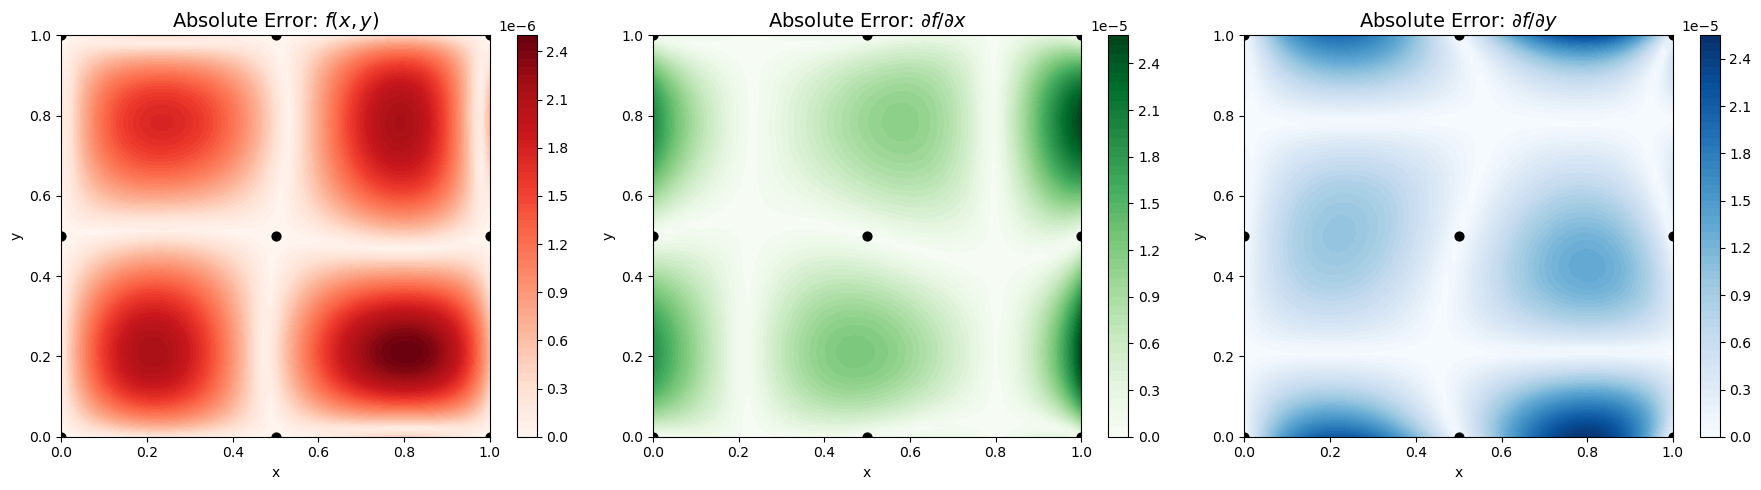

In [22]:
import matplotlib.pyplot as plt

# Compute absolute errors for function and first derivatives
abs_error_func = np.abs(y_func_test - (np.sin(X1_test) * np.cos(X2_test)))
abs_error_dx   = np.abs(y_deriv_x_test - (np.cos(X1_test) * np.cos(X2_test)))
abs_error_dy   = np.abs(y_deriv_y_test - (-np.sin(X1_test) * np.sin(X2_test)))

# Setup figure
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Titles and error arrays
titles = [
   r'Absolute Error: $f(x,y)$',
   r'Absolute Error: $\partial f / \partial x$',
   r'Absolute Error: $\partial f / \partial y$'
]
errors = [abs_error_func, abs_error_dx, abs_error_dy]
cmaps  = ['Reds', 'Greens', 'Blues']

# Plot each contour
for ax, err, title, cmap in zip(axs, errors, titles, cmaps):
   cs = ax.contourf(X1_test, X2_test, err, levels=50, cmap=cmap)
   ax.scatter(X_train[:,0], X_train[:,1], c='k', s=40)
   ax.set_title(title, fontsize=14)
   ax.set_xlabel('x')
   ax.set_ylabel('y')
   fig.colorbar(cs, ax=ax)

plt.tight_layout()
plt.show()

In [23]:
import numpy as np
from jetgp.full_degp.degp import degp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Modules imported successfully for 2D example with second-order derivatives.")

Modules imported successfully for 2D example with second-order derivatives.


In [24]:
X1 = np.array([0.0, 0.5, 1.0])
X2 = np.array([0.0, 0.5, 1.0])
X1_grid, X2_grid = np.meshgrid(X1, X2)
X_train = np.column_stack([X1_grid.flatten(), X2_grid.flatten()])

# True function and derivatives
y_func = np.sin(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_x = np.cos(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_y = -np.sin(X_train[:,0]) * np.sin(X_train[:,1])
y_deriv_xx = -np.sin(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_yy = -np.sin(X_train[:,0]) * np.cos(X_train[:,1])

y_train = [
   y_func.reshape(-1,1),
   y_deriv_x.reshape(-1,1),
   y_deriv_y.reshape(-1,1),
   y_deriv_xx.reshape(-1,1),
   y_deriv_yy.reshape(-1,1)
]

print("X_train shape:", X_train.shape)
print("y_train shapes:", [v.shape for v in y_train])

X_train shape: (9, 2)
y_train shapes: [(9, 1), (9, 1), (9, 1), (9, 1), (9, 1)]


In [25]:
der_indices = [
    [ [[1, 1]], [[2, 1]] ],  # first-order derivatives
    [ [[1, 2]], [[2, 2]] ]   # second-order derivatives
]

# All derivatives at all training points
derivative_locations = []
for i in range(len(der_indices)):
   for j in range(len(der_indices[i])):
         derivative_locations.append([k for k in range(len(X_train))])

print("der_indices:", der_indices)
print("derivative_locations:", derivative_locations)

der_indices: [[[[1, 1]], [[2, 1]]], [[[1, 2]], [[2, 2]]]]
derivative_locations: [[0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8]]


In [26]:
model = degp(X_train, y_train, n_order=2, n_bases=2,
             der_indices=der_indices,
             derivative_locations=derivative_locations,
             normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("2D DEGP model with second-order derivatives initialized.")

2D DEGP model with second-order derivatives initialized.


In [27]:
params =   model.optimize_hyperparameters(
     optimizer='pso',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = 15,
     debug = False
     )
print("Optimized hyperparameters:", params)

Stopping: maximum iterations reached --> 15
Optimized hyperparameters: [ -0.66073543  -0.6925341    0.47166621 -12.43678768]


In [28]:
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)

# Output shape is [n_derivatives + 1, n_points]
# Row 0: function, Row 1: df/dx, Row 2: df/dy, Row 3: d²f/dx², Row 4: d²f/dy²
y_func_pred = y_train_pred[0, :]
y_deriv_x_pred = y_train_pred[1, :]
y_deriv_y_pred = y_train_pred[2, :]
y_deriv_xx_pred = y_train_pred[3, :]
y_deriv_yy_pred = y_train_pred[4, :]

Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[2, 1]], [[1, 2]], [[2, 2]]]


In [29]:
# First-order errors
abs_error_func = np.abs(y_func_pred.flatten() - y_func)
abs_error_dx   = np.abs(y_deriv_x_pred.flatten() - y_deriv_x)
abs_error_dy   = np.abs(y_deriv_y_pred.flatten() - y_deriv_y)

# Second-order main derivative errors
abs_error_dxx  = np.abs(y_deriv_xx_pred.flatten() - y_deriv_xx)
abs_error_dyy  = np.abs(y_deriv_yy_pred.flatten() - y_deriv_yy)

# Print absolute errors
print("Absolute error (function)       :", abs_error_func)
print("Absolute error (derivative x)  :", abs_error_dx)
print("Absolute error (derivative y)  :", abs_error_dy)
print("Absolute error (second x-x)    :", abs_error_dxx)
print("Absolute error (second y-y)    :", abs_error_dyy)

Absolute error (function)       : [1.46046053e-09 6.93145308e-09 5.80099124e-09 4.43802639e-09
 8.90445662e-09 1.74569510e-08 9.79873160e-09 8.34429986e-09
 6.94605018e-09]
Absolute error (derivative x)  : [5.31626076e-10 4.42566095e-10 2.87067692e-09 3.33244032e-09
 3.19915539e-10 1.84083804e-10 3.70129793e-09 1.21737631e-09
 3.37332712e-09]
Absolute error (derivative y)  : [8.50555918e-11 6.19311028e-10 7.28288505e-10 1.29709778e-09
 1.89724875e-10 2.65504285e-11 9.88771255e-10 1.60672387e-09
 1.22619137e-10]
Absolute error (second x-x)    : [1.13530549e-09 1.35025408e-09 1.38770395e-09 1.67162543e-09
 3.39650313e-09 7.87466092e-10 2.36827167e-10 2.62908872e-09
 6.00841432e-10]
Absolute error (second y-y)    : [2.71822247e-10 3.84060161e-09 9.67762981e-10 4.85048081e-10
 6.62737087e-11 1.40338874e-09 2.53917787e-09 1.60612978e-09
 1.61931152e-09]


In [30]:
x1_test = np.linspace(0, 1, 50)
x2_test = np.linspace(0, 1, 50)
X1_test, X2_test = np.meshgrid(x1_test, x2_test)
X_test = np.column_stack([X1_test.flatten(), X2_test.flatten()])

y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)

# Row 0: function, Row 1: df/dx, Row 2: df/dy, Row 3: d²f/dx², Row 4: d²f/dy²
y_func_test = y_test_pred[0, :].reshape(50, 50)
y_deriv_x_test = y_test_pred[1, :].reshape(50, 50)
y_deriv_y_test = y_test_pred[2, :].reshape(50, 50)
y_deriv_xx_test = y_test_pred[3, :].reshape(50, 50)
y_deriv_yy_test = y_test_pred[4, :].reshape(50, 50)

Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[2, 1]], [[1, 2]], [[2, 2]]]


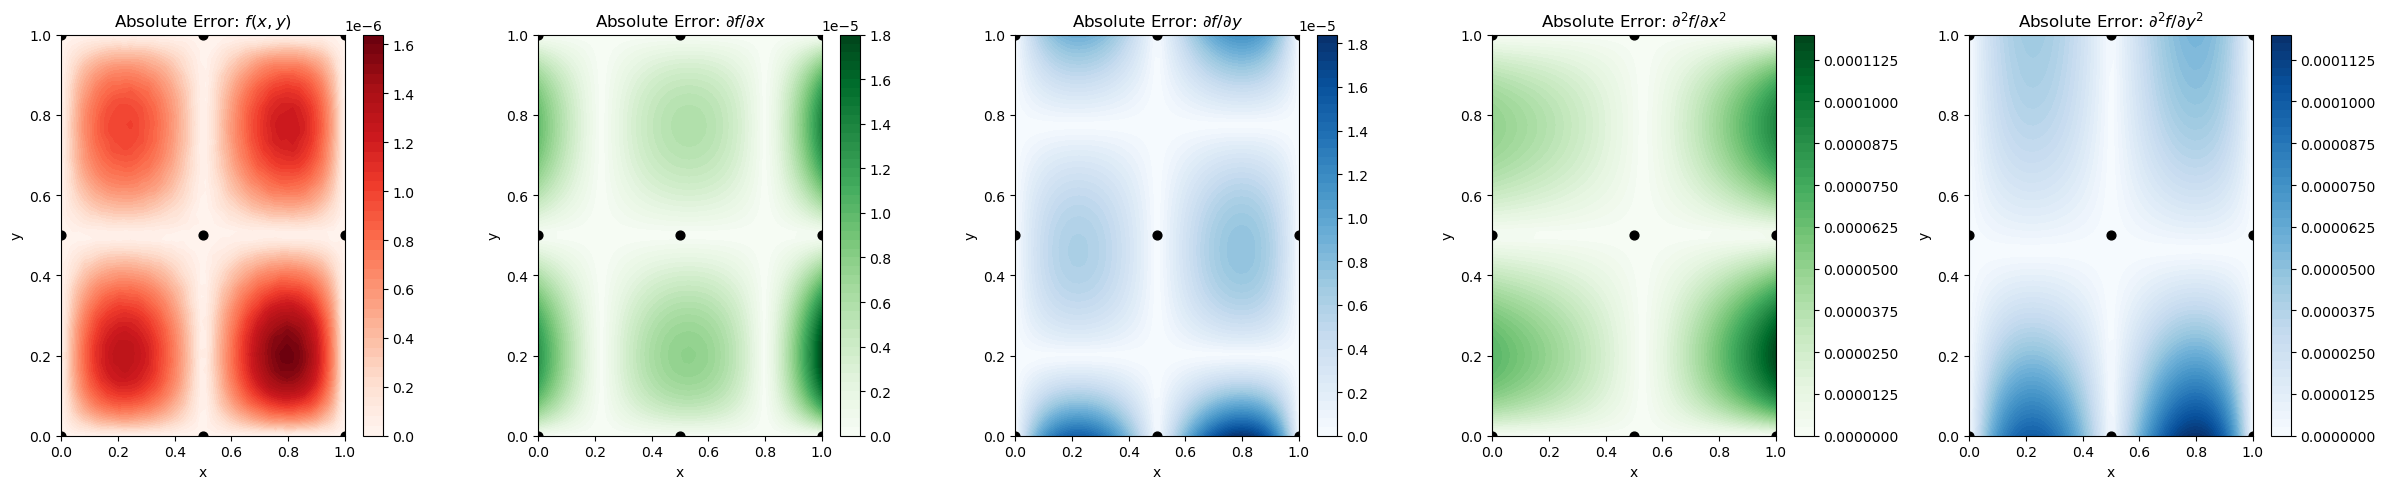

In [31]:
import matplotlib.pyplot as plt

# Compute absolute errors
abs_error_func = np.abs(y_func_test - (np.sin(X1_test) * np.cos(X2_test)))
abs_error_dx   = np.abs(y_deriv_x_test - (np.cos(X1_test) * np.cos(X2_test)))
abs_error_dy   = np.abs(y_deriv_y_test - (-np.sin(X1_test) * np.sin(X2_test)))
abs_error_xx   = np.abs(y_deriv_xx_test - (-np.sin(X1_test) * np.cos(X2_test)))
abs_error_yy   = np.abs(y_deriv_yy_test - (-np.sin(X1_test) * np.cos(X2_test)))

# Setup figure
fig, axs = plt.subplots(1, 5, figsize=(24, 5))

# Titles and errors
titles = [
   r'Absolute Error: $f(x,y)$',
   r'Absolute Error: $\partial f / \partial x$',
   r'Absolute Error: $\partial f / \partial y$',
   r'Absolute Error: $\partial^2 f / \partial x^2$',
   r'Absolute Error: $\partial^2 f / \partial y^2$'
]

errors = [abs_error_func, abs_error_dx, abs_error_dy, abs_error_xx, abs_error_yy]
cmaps  = ['Reds', 'Greens', 'Blues', 'Greens', 'Blues']

# Plot all
for ax, err, title, cmap in zip(axs, errors, titles, cmaps):
   cs = ax.contourf(X1_test, X2_test, err, levels=50, cmap=cmap)
   ax.scatter(X_train[:,0], X_train[:,1], c='k', s=40)
   ax.set_title(title, fontsize=12)
   ax.set_xlabel('x')
   ax.set_ylabel('y')
   fig.colorbar(cs, ax=ax)

plt.tight_layout()
plt.show()

In [32]:
import numpy as np
from jetgp.full_degp.degp import degp
import matplotlib.pyplot as plt

print("Modules imported successfully.")

Modules imported successfully.


In [33]:
# Define training points
X_train = np.linspace(0, 2, 7).reshape(-1, 1)
n_train = len(X_train)

# Identify boundary and interior points
boundary_indices = [0, n_train - 1]  # First and last points
interior_indices = list(range(1, n_train - 1))  # Middle points
all_indices = list(range(n_train))

print(f"Total training points: {n_train}")
print(f"Boundary indices: {boundary_indices}")
print(f"Interior indices: {interior_indices}")

# Define the true function and its derivatives
def f(x):
    return np.sin(2*x) + 0.5*np.cos(5*x)

def df(x):
    return 2*np.cos(2*x) - 2.5*np.sin(5*x)

def d2f(x):
    return -4*np.sin(2*x) - 12.5*np.cos(5*x)

# Compute training data
y_func = f(X_train)
y_deriv1 = df(X_train)
y_deriv2_interior = d2f(X_train[interior_indices])  # Only at interior points!

# Build y_train list
# Note: y_deriv2 only has len(interior_indices) entries, not n_train
y_train = [y_func, y_deriv1, y_deriv2_interior]

print(f"\nTraining data shapes:")
print(f"  Function values: {y_func.shape} (all {n_train} points)")
print(f"  1st derivatives: {y_deriv1.shape} (all {n_train} points)")
print(f"  2nd derivatives: {y_deriv2_interior.shape} (only {len(interior_indices)} interior points)")

Total training points: 7
Boundary indices: [0, 6]
Interior indices: [1, 2, 3, 4, 5]

Training data shapes:
  Function values: (7, 1) (all 7 points)
  1st derivatives: (7, 1) (all 7 points)
  2nd derivatives: (5, 1) (only 5 interior points)


In [34]:
# Derivative specification: 1st and 2nd order derivatives
der_indices = [[[[1, 1]], [[1, 2]]]]

# Derivative locations: specify which points have each derivative
derivative_locations = [
    all_indices,       # 1st derivative (df/dx) at ALL points
    interior_indices   # 2nd derivative (d²f/dx²) at INTERIOR points only
]

print("der_indices:", der_indices)
print("derivative_locations:", derivative_locations)

der_indices: [[[[1, 1]], [[1, 2]]]]
derivative_locations: [[0, 1, 2, 3, 4, 5, 6], [1, 2, 3, 4, 5]]


In [35]:
model = degp(
    X_train,
    y_train,
    n_order=2,
    n_bases=1,
    der_indices=der_indices,
    derivative_locations=derivative_locations,  # Key parameter!
    normalize=True,
    kernel="SE",
    kernel_type="anisotropic"
)

print("DEGP model with heterogeneous derivative coverage initialized.")

DEGP model with heterogeneous derivative coverage initialized.


In [36]:
params = model.optimize_hyperparameters(
    optimizer='pso',
    pop_size=100,
    n_generations=15,
    local_opt_every=15,
    debug=False
)
print("Optimized hyperparameters:", params)

Stopping: maximum iterations reached --> 15
Optimized hyperparameters: [ 5.38173558e-03  4.43679047e-01 -7.46845155e+00]


In [37]:
# Predict with return_deriv=True to get derivative predictions
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)

# Output shape is [n_derivatives + 1, n_points]
# Row 0: function (n_train points)
# Row 1: 1st derivative (n_train points)
# Row 2: 2nd derivative (len(interior_indices) points)
y_func_pred = y_train_pred[0, :]
y_deriv1_pred = y_train_pred[1, :]
y_deriv2_pred = y_train_pred[2, interior_indices]

# Compute errors
abs_error_func = np.abs(y_func_pred.flatten() - y_func.flatten())
abs_error_d1 = np.abs(y_deriv1_pred.flatten() - y_deriv1.flatten())
abs_error_d2 = np.abs(y_deriv2_pred.flatten() - y_deriv2_interior.flatten())

print("Absolute error (function) at all training points:")
print(f"  {abs_error_func}")
print("\nAbsolute error (1st derivative) at all training points:")
print(f"  {abs_error_d1}")
print("\nAbsolute error (2nd derivative) at interior points only:")
print(f"  {abs_error_d2}")

Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[1, 2]]]
Absolute error (function) at all training points:
  [3.99401656e-09 1.14139243e-09 1.37118455e-09 2.44925080e-09
 5.21802701e-09 2.14719420e-09 4.51188864e-10]

Absolute error (1st derivative) at all training points:
  [6.53811583e-09 8.60655813e-09 7.29348371e-09 7.00916236e-09
 5.67615333e-09 3.82377419e-09 1.86330495e-09]

Absolute error (2nd derivative) at interior points only:
  [3.65922670e-09 3.33670620e-08 3.96709394e-08 2.18682903e-08
 1.01349009e-08]


Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[1, 2]]]


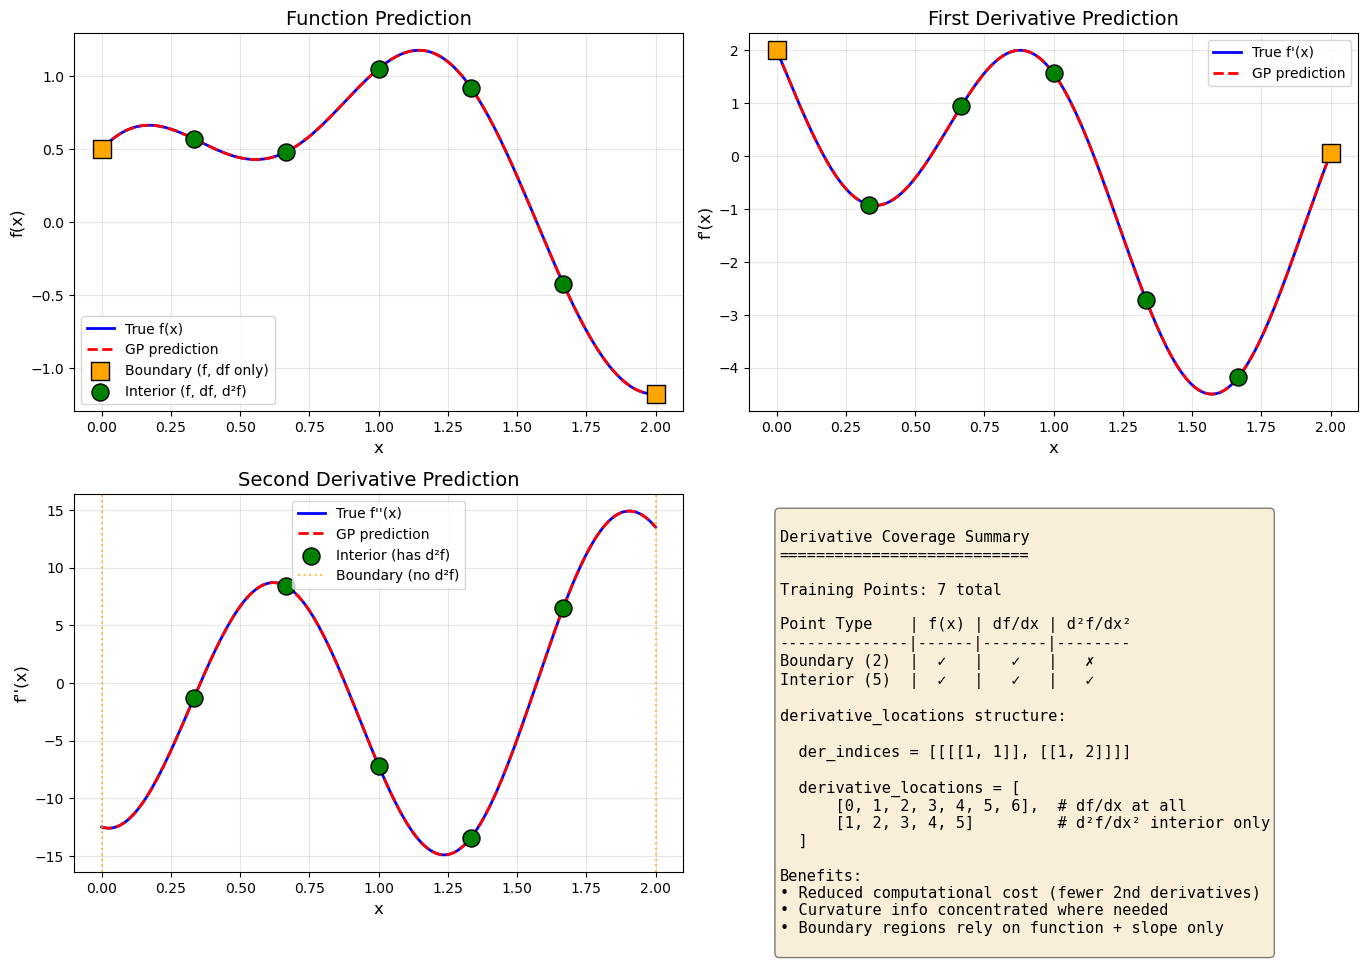

In [38]:
# Generate test points
X_test = np.linspace(0, 2, 200).reshape(-1, 1)
y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)

n_test = len(X_test)

# Row 0: function, Row 1: 1st derivative, Row 2: 2nd derivative
y_func_test = y_test_pred[0, :]
y_d1_test = y_test_pred[1, :]
y_d2_test = y_test_pred[2, :]

# True values for comparison
y_true = f(X_test)
dy_true = df(X_test)
d2y_true = d2f(X_test)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Function ---
ax1 = axes[0, 0]
ax1.plot(X_test, y_true, 'b-', linewidth=2, label='True f(x)')
ax1.plot(X_test, y_func_test, 'r--', linewidth=2, label='GP prediction')
ax1.scatter(X_train[boundary_indices].flatten(), y_func[boundary_indices].flatten(),
            c='orange', s=150, marker='s', zorder=5, edgecolors='black',
            label='Boundary (f, df only)')
ax1.scatter(X_train[interior_indices].flatten(), y_func[interior_indices].flatten(),
            c='green', s=150, marker='o', zorder=5, edgecolors='black',
            label='Interior (f, df, d²f)')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.set_title('Function Prediction', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# --- Plot 2: First Derivative ---
ax2 = axes[0, 1]
ax2.plot(X_test, dy_true, 'b-', linewidth=2, label="True f'(x)")
ax2.plot(X_test, y_d1_test, 'r--', linewidth=2, label='GP prediction')
ax2.scatter(X_train[boundary_indices].flatten(), y_deriv1[boundary_indices].flatten(),
            c='orange', s=150, marker='s', zorder=5, edgecolors='black')
ax2.scatter(X_train[interior_indices].flatten(), y_deriv1[interior_indices].flatten(),
            c='green', s=150, marker='o', zorder=5, edgecolors='black')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel("f'(x)", fontsize=12)
ax2.set_title('First Derivative Prediction', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# --- Plot 3: Second Derivative ---
ax3 = axes[1, 0]
ax3.plot(X_test, d2y_true, 'b-', linewidth=2, label="True f''(x)")
ax3.plot(X_test, y_d2_test, 'r--', linewidth=2, label='GP prediction')
# Only interior points have 2nd derivative training data
ax3.scatter(X_train[interior_indices].flatten(), d2f(X_train[interior_indices]).flatten(),
            c='green', s=150, marker='o', zorder=5, edgecolors='black',
            label='Interior (has d²f)')
# Mark boundary points without 2nd derivative
ax3.axvline(x=X_train[0, 0], color='orange', linestyle=':', alpha=0.7)
ax3.axvline(x=X_train[-1, 0], color='orange', linestyle=':', alpha=0.7,
            label='Boundary (no d²f)')
ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel("f''(x)", fontsize=12)
ax3.set_title('Second Derivative Prediction', fontsize=14)
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

# --- Plot 4: Derivative Coverage Visualization ---
ax4 = axes[1, 1]
ax4.axis('off')

coverage_text = """
Derivative Coverage Summary
===========================

Training Points: 7 total

Point Type    | f(x) | df/dx | d²f/dx²
--------------|------|-------|--------
Boundary (2)  |  ✓   |   ✓   |   ✗
Interior (5)  |  ✓   |   ✓   |   ✓

derivative_locations structure:

  der_indices = [[[[1, 1]], [[1, 2]]]]

  derivative_locations = [
      [0, 1, 2, 3, 4, 5, 6],  # df/dx at all
      [1, 2, 3, 4, 5]         # d²f/dx² interior only
  ]

Benefits:
• Reduced computational cost (fewer 2nd derivatives)
• Curvature info concentrated where needed
• Boundary regions rely on function + slope only
"""

ax4.text(0.05, 0.95, coverage_text, transform=ax4.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [39]:
# Evaluate prediction accuracy in different regions
boundary_test_mask = (X_test.flatten() < 0.3) | (X_test.flatten() > 1.7)
interior_test_mask = ~boundary_test_mask

func_error_boundary = np.mean(np.abs(y_func_test[boundary_test_mask].flatten() -
                                      y_true[boundary_test_mask].flatten()))
func_error_interior = np.mean(np.abs(y_func_test[interior_test_mask].flatten() -
                                      y_true[interior_test_mask].flatten()))

d2_error_boundary = np.mean(np.abs(y_d2_test[boundary_test_mask].flatten() -
                                    d2y_true[boundary_test_mask].flatten()))
d2_error_interior = np.mean(np.abs(y_d2_test[interior_test_mask].flatten() -
                                    d2y_true[interior_test_mask].flatten()))

print("Mean Absolute Error Comparison:")
print(f"\nFunction prediction:")
print(f"  Boundary region: {func_error_boundary:.6f}")
print(f"  Interior region: {func_error_interior:.6f}")
print(f"\nSecond derivative prediction:")
print(f"  Boundary region: {d2_error_boundary:.6f}")
print(f"  Interior region: {d2_error_interior:.6f}")

Mean Absolute Error Comparison:

Function prediction:
  Boundary region: 0.000000
  Interior region: 0.000000

Second derivative prediction:
  Boundary region: 0.000010
  Interior region: 0.000000


In [40]:
import numpy as np
from jetgp.full_degp.degp import degp
import matplotlib.pyplot as plt

print("Modules imported successfully.")

Modules imported successfully.


In [41]:
np.random.seed(42)

# 3D input — sample a small grid
x_vals = np.linspace(0, 1, 4)
g = np.array([[x1, x2, x3]
              for x1 in x_vals for x2 in x_vals for x3 in x_vals])
X_train = g

def f(X):      return np.sin(X[:, 0]) + np.cos(X[:, 1]) + X[:, 2] ** 2
def df_dx1(X): return np.cos(X[:, 0])
def df_dx2(X): return -np.sin(X[:, 1])
def df_dx3(X): return 2.0 * X[:, 2]   # NOT included in training

y_func  = f(X_train).reshape(-1, 1)
y_dx1   = df_dx1(X_train).reshape(-1, 1)
y_dx2   = df_dx2(X_train).reshape(-1, 1)
y_train = [y_func, y_dx1, y_dx2]   # df/dx3 deliberately omitted

print(f"Training points : {X_train.shape[0]}")
print(f"Training outputs: f, df/dx1, df/dx2  (df/dx3 NOT provided)")

Training points : 64
Training outputs: f, df/dx1, df/dx2  (df/dx3 NOT provided)


In [42]:
# Only dx1 and dx2 are in the training set
der_indices = [[[[1, 1]], [[2, 1]]]]

n_train = len(X_train)
derivative_locations = [
    list(range(n_train)),   # df/dx1 at all points
    list(range(n_train)),   # df/dx2 at all points
]

print("der_indices          :", der_indices)
print("derivative_locations : 2 entries, each covering all", n_train, "points")

der_indices          : [[[[1, 1]], [[2, 1]]]]
derivative_locations : 2 entries, each covering all 64 points


In [43]:
# n_bases=3 because the input space is 3-dimensional.
# This means the OTI module includes basis units e1, e2, e3
# for all three coordinate directions, even though dx3 is not trained.
model = degp(
    X_train, y_train,
    n_order=1, n_bases=3,
    der_indices=der_indices,
    derivative_locations=derivative_locations,
    normalize=True,
    kernel="SE", kernel_type="anisotropic"
)

print("DEGP model (3D, training dx1+dx2 only) initialized.")

DEGP model (3D, training dx1+dx2 only) initialized.


In [44]:
params = model.optimize_hyperparameters(
    optimizer='powell',
    n_restart_optimizer=5,
    debug=False
)
print("Optimized hyperparameters:", params)

Optimized hyperparameters: [ -0.7445372   -0.16844792   1.12551596   3.19019142 -12.79212672]


In [45]:
np.random.seed(7)
X_test = np.random.uniform(0, 1, (50, 3))

# Request df/dx3 via derivs_to_predict — it was NOT in the training set
pred = model.predict(
    X_test, params,
    calc_cov=False,
    return_deriv=True,
    derivs_to_predict=[[[3, 1]]]   # dx3 only
)

# pred shape: (2, n_test) — row 0 = f, row 1 = df/dx3
f_pred   = pred[0, :]
dx3_pred = pred[1, :]

dx3_true = df_dx3(X_test).flatten()
f_true   = f(X_test).flatten()

rmse_f   = float(np.sqrt(np.mean((f_pred - f_true) ** 2)))
rmse_dx3 = float(np.sqrt(np.mean((dx3_pred - dx3_true) ** 2)))
corr_dx3 = float(np.corrcoef(dx3_pred, dx3_true)[0, 1])

print(f"Function RMSE            : {rmse_f:.4e}")
print(f"df/dx3 RMSE (untrained)  : {rmse_dx3:.4e}")
print(f"df/dx3 correlation       : {corr_dx3:.4f}")

Function RMSE            : 3.3476e-01
df/dx3 RMSE (untrained)  : 2.9840e+00
df/dx3 correlation       : -0.0001


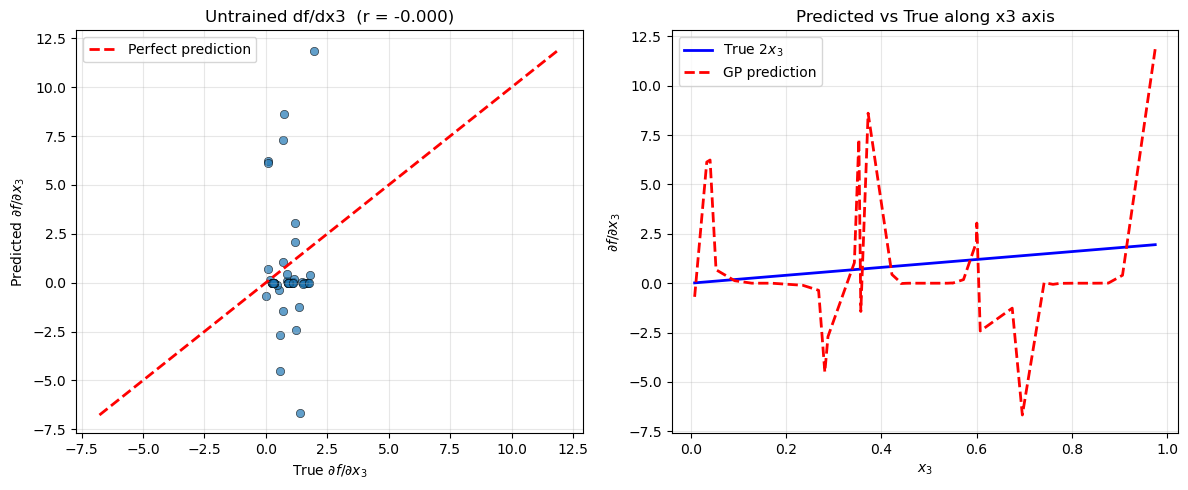

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: predicted vs true df/dx3
axes[0].scatter(dx3_true, dx3_pred, alpha=0.7, edgecolors='k', linewidths=0.5)
lims = [min(dx3_true.min(), dx3_pred.min()) - 0.1,
        max(dx3_true.max(), dx3_pred.max()) + 0.1]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel(r'True $\partial f / \partial x_3$')
axes[0].set_ylabel(r'Predicted $\partial f / \partial x_3$')
axes[0].set_title(f'Untrained df/dx3  (r = {corr_dx3:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sort by x3 for a clean line plot
sort_idx = np.argsort(X_test[:, 2])
axes[1].plot(X_test[sort_idx, 2], dx3_true[sort_idx],
             'b-', linewidth=2, label=r'True $2x_3$')
axes[1].plot(X_test[sort_idx, 2], dx3_pred[sort_idx],
             'r--', linewidth=2, label='GP prediction')
axes[1].set_xlabel(r'$x_3$')
axes[1].set_ylabel(r'$\partial f / \partial x_3$')
axes[1].set_title('Predicted vs True along x3 axis')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()